# PTGP Demo

Test all three models (GP, VFE, SVGP) on synthetic 1D regression data using PyMC priors.

In [1]:
import numpy as np
import pymc as pm
import pytensor
import pytensor.tensor as pt
import matplotlib.pyplot as plt

import ptgp as pg

## Generate data, student-t noise

Text(0.5, 1.0, 'Training data')

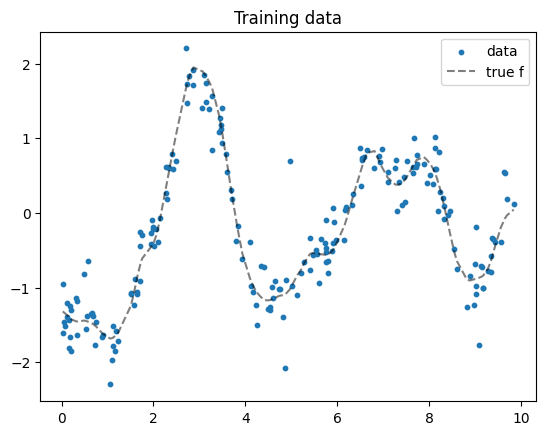

In [2]:
rng = np.random.default_rng(600)
N = 200
noise_std = 0.2
nu_true = 6

# True GP hyperparameters
eta_true = 1.3
ls_true = 1.0

X_train = np.sort(rng.uniform(0, 10, N))[:, None]
X_test = np.linspace(-1, 11, 200)[:, None]

# Draw from a GP prior with Matern-5/2 kernel
K = eta_true**2 * pg.kernels.Matern52(input_dim=1, ls=ls_true)
K = K(X_train, X_train).eval() + 1e-6 * np.eye(N)

f_train = rng.multivariate_normal(np.zeros(N), K)
y_train = f_train + noise_std * rng.standard_t(df=nu_true, size=N)

plt.scatter(X_train, y_train, s=10, label="data")
plt.plot(X_train, f_train, "k--", alpha=0.5, label="true f")
plt.legend()
plt.title("Training data")

## Exact GP

In [3]:
import time
import scipy.optimize

X_var = pt.matrix("X")
y_var = pt.vector("y")

with pm.Model() as gp_model:
    ls = pm.HalfFlat("ls")
    eta = pm.Exponential("eta", scale=2.0)
    sigma = pm.HalfNormal("sigma", sigma=1.0)

    kernel = eta**2 * pg.kernels.Matern52(input_dim=1, ls=ls)
    gp = pg.gp.Unapproximated(kernel=kernel, sigma=sigma)

    fun, theta0, unpack_to_shared, shared_params, shared_extras = (
        pg.optim.compile_scipy_objective(
            pg.objectives.marginal_log_likelihood,
            gp,
            X_var,
            y_var,
        )
    )

t0 = time.time()
result = scipy.optimize.minimize(
    fun,
    theta0,
    args=(X_train, y_train),
    jac=True,
    method="L-BFGS-B",
)
elapsed = time.time() - t0
unpack_to_shared(result.x)
print(
    f"converged in {result.nit} iterations, loss = {result.fun:.4f}, time = {elapsed:.2f}s"
)

params = pg.optim.get_trained_params(gp_model, shared_params)
print(f"\nRecovered: {params}")
print(f"True:      eta={eta_true}, ls={ls_true}, noise_std={noise_std}")

/Users/thomaspinder/Library/Application Support/hatch/env/virtual/ptgp/X2kn2EiV/ptgp/lib/python3.12/site-packages/pytensor/gradient.py:1327: FutureWarning: SpecifyAssumptions should implement `pullback` instead of `L_op`/`grad`. Direct `L_op`/`grad` implementations are deprecated and will stop being called in a future version.
  input_grads = node.op.pullback(inputs, node.outputs, new_output_grads)


converged in 12 iterations, loss = 78.2532, time = 2.78s

Recovered: {'ls': 0.9194395759943371, 'eta': 1.0921330911684093, 'sigma': 0.2908386606913514}
True:      eta=1.3, ls=1.0, noise_std=0.2


Text(0.5, 1.0, 'Exact GP')

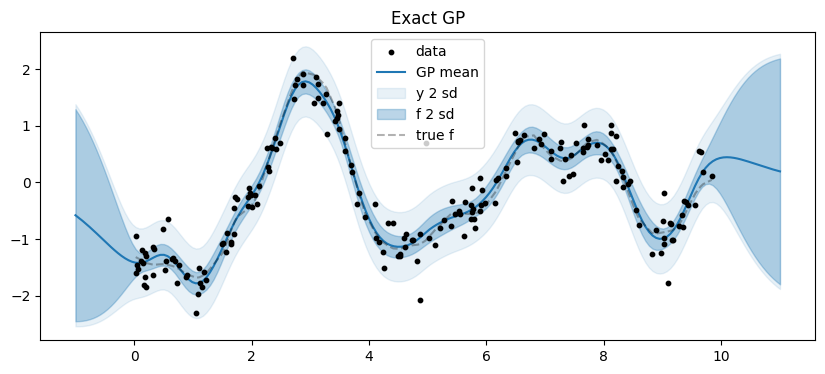

In [4]:
X_new_var = pt.matrix("X_new")
predict_gp = pg.optim.compile_predict(
    gp,
    X_new_var,
    gp_model,
    shared_params,
    X_train=X_train,
    y_train=y_train,
)
predict_gp_y = pg.optim.compile_predict(
    gp,
    X_new_var,
    gp_model,
    shared_params,
    X_train=X_train,
    y_train=y_train,
    incl_lik=True,
)

mu_gp, var_gp = predict_gp(X_test)
_, var_gp_y = predict_gp_y(X_test)
sd_gp = np.sqrt(var_gp)
sd_gp_y = np.sqrt(var_gp_y)

plt.figure(figsize=(10, 4))
plt.scatter(X_train, y_train, s=10, c="k", zorder=3, label="data")
plt.plot(X_test, mu_gp, "C0", label="GP mean")
plt.fill_between(
    X_test.ravel(),
    mu_gp - 2 * sd_gp_y,
    mu_gp + 2 * sd_gp_y,
    alpha=0.1,
    color="C0",
    label="y 2 sd",
)
plt.fill_between(
    X_test.ravel(),
    mu_gp - 2 * sd_gp,
    mu_gp + 2 * sd_gp,
    alpha=0.3,
    color="C0",
    label="f 2 sd",
)
plt.plot(X_train, f_train, "k--", alpha=0.3, label="true f")
plt.legend()
plt.title("Exact GP")

## VFE (Sparse GP -- collapsed bound)

In [5]:
M = 20
Z_init = np.linspace(-0.5, 10.5, M)[:, None]

Z_var = pt.matrix("Z")

with pm.Model() as vfe_model:
    ls = pm.HalfFlat("ls")
    eta = pm.Exponential("eta", lam=1.0)
    sigma = pm.HalfNormal("sigma", sigma=1.0)

    vfe = pg.gp.VFE(
        kernel=eta**2 * pg.kernels.Matern52(input_dim=1, ls=ls),
        sigma=sigma,
        inducing_variable=pg.inducing.Points(Z_var),
    )

fun_vfe, theta0_vfe, unpack_to_shared_vfe, shared_params_vfe, shared_extras_vfe = (
    pg.optim.compile_scipy_objective(
        pg.objectives.collapsed_elbo,
        vfe,
        X_var,
        y_var,
        model=vfe_model,
        extra_vars=[Z_var],
        extra_init=[Z_init],
    )
)

t0 = time.time()
result_vfe = scipy.optimize.minimize(
    fun_vfe,
    theta0_vfe,
    args=(X_train, y_train),
    jac=True,
    method="L-BFGS-B",
)
elapsed = time.time() - t0
unpack_to_shared_vfe(result_vfe.x)
print(
    f"converged in {result_vfe.nit} iterations, loss = {result_vfe.fun:.4f}, time = {elapsed:.2f}s"
)

params_vfe = pg.optim.get_trained_params(vfe_model, shared_params_vfe)
print(f"\nRecovered: {params_vfe}")
print(f"True:      eta={eta_true}, ls={ls_true}, noise_std={noise_std}")

/Users/thomaspinder/Library/Application Support/hatch/env/virtual/ptgp/X2kn2EiV/ptgp/lib/python3.12/site-packages/pytensor/gradient.py:1327: FutureWarning: SpecifyAssumptions should implement `pullback` instead of `L_op`/`grad`. Direct `L_op`/`grad` implementations are deprecated and will stop being called in a future version.
  input_grads = node.op.pullback(inputs, node.outputs, new_output_grads)


converged in 68 iterations, loss = 80.8569, time = 4.49s

Recovered: {'ls': 1.0811106535210258, 'eta': 1.135312488951191, 'sigma': 0.29818042214168033}
True:      eta=1.3, ls=1.0, noise_std=0.2


Text(0.5, 1.0, 'VFE (M=20)')

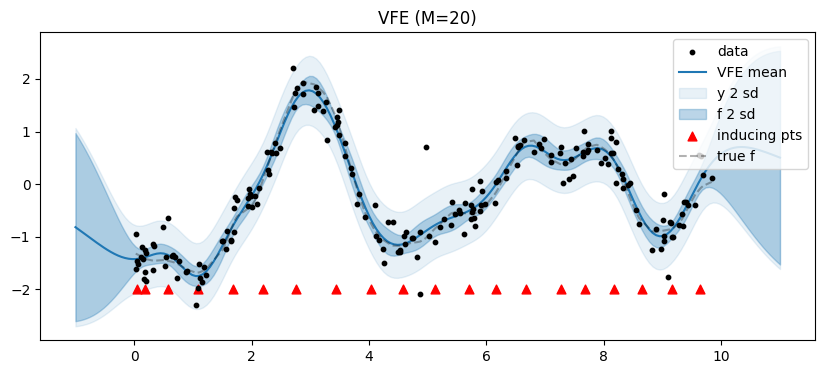

In [6]:
predict_vfe = pg.optim.compile_predict(
    vfe,
    X_new_var,
    vfe_model,
    shared_params_vfe,
    X_train=X_train,
    y_train=y_train,
    extra_vars=[Z_var],
    shared_extras=shared_extras_vfe,
)
predict_vfe_y = pg.optim.compile_predict(
    vfe,
    X_new_var,
    vfe_model,
    shared_params_vfe,
    X_train=X_train,
    y_train=y_train,
    extra_vars=[Z_var],
    shared_extras=shared_extras_vfe,
    incl_lik=True,
)

mu_vfe, var_vfe = predict_vfe(X_test)
_, var_vfe_y = predict_vfe_y(X_test)
sd_vfe = np.sqrt(var_vfe)
sd_vfe_y = np.sqrt(var_vfe_y)

Z_final = shared_extras_vfe[0].get_value()

plt.figure(figsize=(10, 4))
plt.scatter(X_train, y_train, s=10, c="k", zorder=3, label="data")
plt.plot(X_test, mu_vfe, "C0", label="VFE mean")
plt.fill_between(
    X_test.ravel(),
    mu_vfe - 2 * sd_vfe_y,
    mu_vfe + 2 * sd_vfe_y,
    alpha=0.1,
    color="C0",
    label="y 2 sd",
)
plt.fill_between(
    X_test.ravel(),
    mu_vfe - 2 * sd_vfe,
    mu_vfe + 2 * sd_vfe,
    alpha=0.3,
    color="C0",
    label="f 2 sd",
)
plt.scatter(Z_final, np.zeros(M) - 2, marker="^", c="r", s=40, label="inducing pts")
plt.plot(X_train, f_train, "k--", alpha=0.3, label="true f")
plt.legend(loc="upper right")
plt.title(f"VFE (M={M})")

## SVGP (Stochastic Variational GP)

Minibatch training with variational parameters.

In [7]:
M_svgp = 20

Z_init_kernel = pg.kernels.Matern52(input_dim=1, ls=1.0)
Z_greedy = pg.inducing.greedy_variance_init(X_train, M_svgp, Z_init_kernel, rng=42).Z

q_mu_var = pt.vector("q_mu")
q_sqrt_var = pt.matrix("q_sqrt")
Z_var = pt.matrix("Z")

with pm.Model() as svgp_model:
    ls = pm.HalfFlat("ls")
    eta = pm.Exponential("eta", lam=1.0)
    sigma = pm.HalfNormal("sigma", sigma=1.0)
    nu = pm.Gamma("nu", alpha=2, beta=0.1)

    kernel = eta**2 * pg.kernels.Matern52(input_dim=1, ls=ls)
    lik = pg.likelihoods.StudentT(sigma=sigma, nu=nu)

    svgp = pg.gp.SVGP(
        kernel=kernel,
        likelihood=lik,
        inducing_variable=pg.inducing.Points(Z_var),
        q_mu=q_mu_var,
        q_sqrt=q_sqrt_var,
    )

### Training strategy

**Inducing point init.** `greedy_variance_init` picks a space-filling subset of `X_train` via pivoted Cholesky (Burt et al. 2020). It's a strong enough starting point that `Z` often doesn't need further optimization — but here we still fine-tune it in phase 2 to demonstrate the mechanics.

**Two-phase training.** `svgp` is built once with `Z_var` as a symbolic placeholder. Phase 1 pins `Z_var` to `Z_greedy` via `frozen_vars` and trains only the hyperparameters and variational parameters. Phase 2 moves `Z_var` into `extra_vars`, making `Z` trainable, and recompiles using the state carried over from phase 1.

**Learning rates.** Phase 1 runs a single exponential-decay schedule from `1e-2` down to `5e-3` over `n_phase1` steps. Phase 2 uses per-group rates:

- `hyp` — fixed at 50% of phase 1's final LR (gentle fine-tuning once hyperparameters are near optimum).
- `var` — continues phase 1's decay seamlessly, starting at `5e-3`.
- `Z` — its own small steady rate (`5e-3`) for the newly unfrozen inducing points.

In [8]:
X_batch_var = pt.matrix("X_batch")
y_batch_var = pt.vector("y_batch")
batch_size = 32
n_phase1 = 1000
n_phase2 = 1000


def elbo_scaled(model, X, y):
    return pg.objectives.elbo(model, X, y, n_data=N)


# ----- Phase 1: Z frozen -----
phase1_base_lr = 1e-2
phase1_decay_rate = 0.5
phase1_final_lr = phase1_base_lr * phase1_decay_rate  # LR at t=n_phase1

train_step_1, shared_params_1, shared_extras_1 = pg.optim.compile_training_step(
    elbo_scaled,
    svgp,
    X_batch_var,
    y_batch_var,
    model=svgp_model,
    extra_vars=[q_mu_var, q_sqrt_var],
    extra_init=[np.zeros(M_svgp), np.eye(M_svgp)],
    frozen_vars={Z_var: Z_greedy},
    learning_rate=pg.optim.schedules.exponential_decay(
        phase1_base_lr,
        decay_rate=phase1_decay_rate,
        decay_steps=n_phase1,
    ),
)

losses = []
t0 = time.time()
for step in range(n_phase1):
    idx = rng.choice(N, size=batch_size, replace=False)
    loss = train_step_1(X_train[idx], y_train[idx])
    losses.append(float(loss))
    if step % 250 == 0:
        print(f"[phase 1, Z frozen]    Step {step}: loss = {loss:.2f}")
elapsed_1 = time.time() - t0

# ----- Phase 2: Z trainable, per-group LRs -----
hyp_value_vars = [svgp_model.rvs_to_values[rv] for rv in (ls, eta, sigma, nu)]
phase2_hyp_lr = 0.5 * phase1_final_lr

train_step_2, shared_params_svgp, shared_extras_svgp = pg.optim.compile_training_step(
    elbo_scaled,
    svgp,
    X_batch_var,
    y_batch_var,
    model=svgp_model,
    extra_vars=[q_mu_var, q_sqrt_var, Z_var],
    extra_init=[np.zeros(M_svgp), np.eye(M_svgp), Z_greedy],
    param_groups={
        "hyp": hyp_value_vars,
        "var": [q_mu_var, q_sqrt_var],
        "Z": [Z_var],
    },
    learning_rate={
        "hyp": phase2_hyp_lr,
        "var": pg.optim.schedules.exponential_decay(
            phase1_final_lr,
            decay_rate=phase1_decay_rate,
            decay_steps=n_phase1,
        ),
        "Z": 5e-3,
    },
)

# Carry phase-1 state into phase 2.
for vv, sh1 in shared_params_1.items():
    shared_params_svgp[vv].set_value(sh1.get_value())
shared_extras_svgp[0].set_value(shared_extras_1[0].get_value())
shared_extras_svgp[1].set_value(shared_extras_1[1].get_value())

t0 = time.time()
for step in range(n_phase2):
    idx = rng.choice(N, size=batch_size, replace=False)
    loss = train_step_2(X_train[idx], y_train[idx])
    losses.append(float(loss))
    if step % 250 == 0:
        print(f"[phase 2, Z trainable] Step {step}: loss = {loss:.2f}")
elapsed_2 = time.time() - t0

params_svgp = pg.optim.get_trained_params(svgp_model, shared_params_svgp)
print(f"\nRecovered: {params_svgp}")
print(f"True:      eta={eta_true}, ls={ls_true}, noise_std={noise_std}, nu={nu_true}")
print(
    f"\ntraining time: phase 1 = {elapsed_1:.2f}s, phase 2 = {elapsed_2:.2f}s, total = {elapsed_1 + elapsed_2:.2f}s"
)

/Users/thomaspinder/Library/Application Support/hatch/env/virtual/ptgp/X2kn2EiV/ptgp/lib/python3.12/site-packages/pytensor/gradient.py:1327: FutureWarning: SpecifyAssumptions should implement `pullback` instead of `L_op`/`grad`. Direct `L_op`/`grad` implementations are deprecated and will stop being called in a future version.
  input_grads = node.op.pullback(inputs, node.outputs, new_output_grads)
/Users/thomaspinder/Library/Application Support/hatch/env/virtual/ptgp/X2kn2EiV/ptgp/lib/python3.12/site-packages/pytensor/gradient.py:1327: FutureWarning: SpecifyAssumptions should implement `pullback` instead of `L_op`/`grad`. Direct `L_op`/`grad` implementations are deprecated and will stop being called in a future version.
  input_grads = node.op.pullback(inputs, node.outputs, new_output_grads)


[phase 1, Z frozen]    Step 0: loss = 372.60
[phase 1, Z frozen]    Step 250: loss = 78.19
[phase 1, Z frozen]    Step 500: loss = 117.81
[phase 1, Z frozen]    Step 750: loss = 47.92


/Users/thomaspinder/Library/Application Support/hatch/env/virtual/ptgp/X2kn2EiV/ptgp/lib/python3.12/site-packages/pytensor/gradient.py:1327: FutureWarning: SpecifyAssumptions should implement `pullback` instead of `L_op`/`grad`. Direct `L_op`/`grad` implementations are deprecated and will stop being called in a future version.
  input_grads = node.op.pullback(inputs, node.outputs, new_output_grads)
/Users/thomaspinder/Library/Application Support/hatch/env/virtual/ptgp/X2kn2EiV/ptgp/lib/python3.12/site-packages/pytensor/gradient.py:1327: FutureWarning: SpecifyAssumptions should implement `pullback` instead of `L_op`/`grad`. Direct `L_op`/`grad` implementations are deprecated and will stop being called in a future version.
  input_grads = node.op.pullback(inputs, node.outputs, new_output_grads)


[phase 2, Z trainable] Step 0: loss = 32.20
[phase 2, Z trainable] Step 250: loss = 70.71
[phase 2, Z trainable] Step 500: loss = 104.67
[phase 2, Z trainable] Step 750: loss = 27.33

Recovered: {'ls': 1.1077014924603485, 'eta': 1.1559159210007832, 'sigma': 0.2309551103814799, 'nu': 5.364688219581478}
True:      eta=1.3, ls=1.0, noise_std=0.2, nu=6

training time: phase 1 = 3.72s, phase 2 = 3.96s, total = 7.68s


Text(0.5, 1.0, 'SVGP training loss')

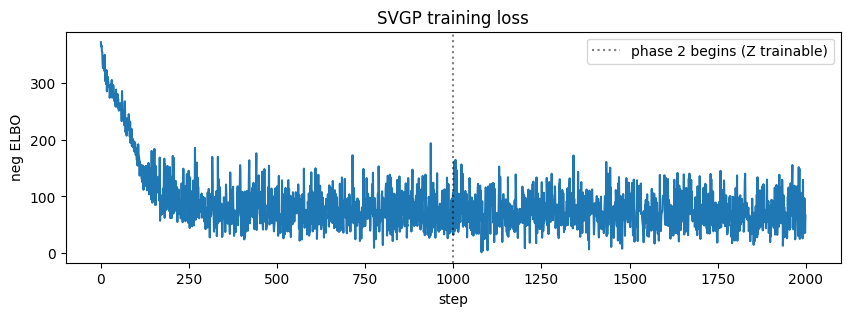

In [9]:
plt.figure(figsize=(10, 3))
plt.plot(losses)
plt.axvline(
    n_phase1, color="k", linestyle=":", alpha=0.5, label="phase 2 begins (Z trainable)"
)
plt.xlabel("step")
plt.ylabel("neg ELBO")
plt.legend()
plt.title("SVGP training loss")

Text(0.5, 1.0, 'SVGP (M=20)')

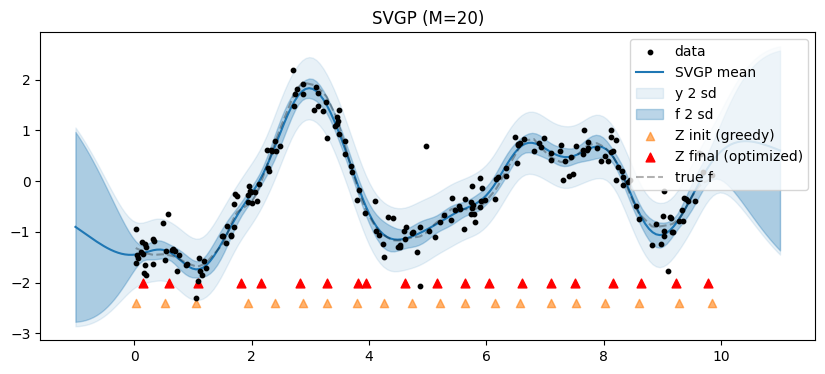

In [10]:
predict_svgp = pg.optim.compile_predict(
    svgp,
    X_new_var,
    svgp_model,
    shared_params_svgp,
    extra_vars=[q_mu_var, q_sqrt_var, Z_var],
    shared_extras=shared_extras_svgp,
)
predict_svgp_y = pg.optim.compile_predict(
    svgp,
    X_new_var,
    svgp_model,
    shared_params_svgp,
    extra_vars=[q_mu_var, q_sqrt_var, Z_var],
    shared_extras=shared_extras_svgp,
    incl_lik=True,
)

mu_svgp, var_svgp = predict_svgp(X_test)
mu_svgp_y, var_svgp_y = predict_svgp_y(X_test)
sd_svgp = np.sqrt(var_svgp)
sd_svgp_y = np.sqrt(var_svgp_y)

plt.figure(figsize=(10, 4))
plt.scatter(X_train, y_train, s=10, c="k", zorder=3, label="data")
plt.plot(X_test, mu_svgp, "C0", label="SVGP mean")
plt.fill_between(
    X_test.ravel(),
    mu_svgp_y - 2 * sd_svgp_y,
    mu_svgp_y + 2 * sd_svgp_y,
    alpha=0.1,
    color="C0",
    label="y 2 sd",
)
plt.fill_between(
    X_test.ravel(),
    mu_svgp - 2 * sd_svgp,
    mu_svgp + 2 * sd_svgp,
    alpha=0.3,
    color="C0",
    label="f 2 sd",
)
Z_opt = shared_extras_svgp[2].get_value()
plt.scatter(
    Z_greedy.ravel(),
    np.zeros(M_svgp) - 2.4,
    marker="^",
    c="C1",
    s=35,
    alpha=0.6,
    label="Z init (greedy)",
)
plt.scatter(
    Z_opt.ravel(),
    np.zeros(M_svgp) - 2.0,
    marker="^",
    c="r",
    s=40,
    label="Z final (optimized)",
)
plt.plot(X_train, f_train, "k--", alpha=0.3, label="true f")
plt.legend(loc="upper right")
plt.title(f"SVGP (M={M_svgp})")

## VFF (Variational Fourier Features)

Inter-domain inducing variables: a Fourier basis defined on `[a, b]` instead of pseudo-inputs `Z`. For Matérn52 VFF the interval must cover the prediction range because reference edge covariances are not implemented; keep a buffer around the plotted range to avoid boundary artifacts. The structured `Kuu = diag(d) + UUᵀ` is solved analytically (Woodbury), so each step is O(M) instead of O(M³).

In [11]:
vff_pad = 1.0
f_vff = pg.FourierFeatures1D(
    a=float(min(X_train.min(), X_test.min()) - vff_pad),
    b=float(max(X_train.max(), X_test.max()) + vff_pad),
    num_frequencies=15,
)
M_vff = f_vff.num_inducing  # 2K+1

q_mu_vff = pt.vector("q_mu_vff")
q_sqrt_vff = pt.matrix("q_sqrt_vff")

with pm.Model() as vff_model:
    ls = pm.HalfFlat("ls")
    eta = pm.Exponential("eta", lam=1.0)
    sigma = pm.HalfNormal("sigma", sigma=1.0)

    svgp_vff = pg.gp.SVGP(
        kernel=eta**2 * pg.kernels.Matern52(input_dim=1, ls=ls),
        likelihood=pg.likelihoods.Gaussian(sigma=sigma),
        inducing_variable=f_vff,
        q_mu=q_mu_vff,
        q_sqrt=q_sqrt_vff,
    )

train_step_vff, shared_params_vff, shared_extras_vff = pg.optim.compile_training_step(
    pg.objectives.elbo,
    svgp_vff,
    X_var,
    y_var,
    model=vff_model,
    extra_vars=[q_mu_vff, q_sqrt_vff],
    extra_init=[np.zeros(M_vff), np.eye(M_vff)],
    learning_rate=1e-2,
)

t0 = time.time()
losses_vff = [float(train_step_vff(X_train, y_train)) for _ in range(800)]
elapsed_vff = time.time() - t0

print(
    f"M = 2K+1 = {M_vff}, neg-ELBO: {losses_vff[0]:.1f} -> {losses_vff[-1]:.1f}, time = {elapsed_vff:.2f}s"
)
print(f"\nRecovered: {pg.optim.get_trained_params(vff_model, shared_params_vff)}")
print(f"True:      eta={eta_true}, ls={ls_true}, noise_std={noise_std}")

/Users/thomaspinder/Library/Application Support/hatch/env/virtual/ptgp/X2kn2EiV/ptgp/lib/python3.12/site-packages/pytensor/gradient.py:1327: FutureWarning: SpecifyAssumptions should implement `pullback` instead of `L_op`/`grad`. Direct `L_op`/`grad` implementations are deprecated and will stop being called in a future version.
  input_grads = node.op.pullback(inputs, node.outputs, new_output_grads)
/Users/thomaspinder/Library/Application Support/hatch/env/virtual/ptgp/X2kn2EiV/ptgp/lib/python3.12/site-packages/pytensor/gradient.py:1327: FutureWarning: SpecifyAssumptions should implement `pullback` instead of `L_op`/`grad`. Direct `L_op`/`grad` implementations are deprecated and will stop being called in a future version.
  input_grads = node.op.pullback(inputs, node.outputs, new_output_grads)


M = 2K+1 = 31, neg-ELBO: 384.7 -> 80.7, time = 6.92s

Recovered: {'ls': 0.8512829957954589, 'eta': 0.930517609028257, 'sigma': 0.29671216214663804}
True:      eta=1.3, ls=1.0, noise_std=0.2


Text(0.5, 1.0, 'VFF-SVGP (M = 2K+1 = 31)')

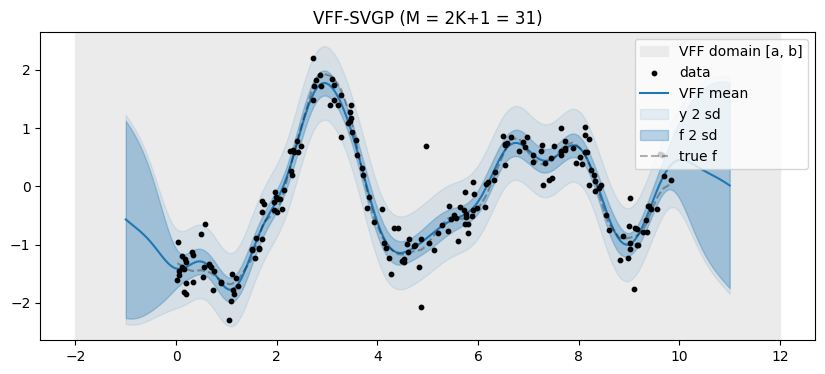

In [12]:
predict_vff = pg.optim.compile_predict(
    svgp_vff,
    X_new_var,
    vff_model,
    shared_params_vff,
    extra_vars=[q_mu_vff, q_sqrt_vff],
    shared_extras=shared_extras_vff,
)
predict_vff_y = pg.optim.compile_predict(
    svgp_vff,
    X_new_var,
    vff_model,
    shared_params_vff,
    extra_vars=[q_mu_vff, q_sqrt_vff],
    shared_extras=shared_extras_vff,
    incl_lik=True,
)
mu_vff, var_vff = predict_vff(X_test)
_, var_vff_y = predict_vff_y(X_test)
sd_vff = np.sqrt(var_vff)
sd_vff_y = np.sqrt(var_vff_y)

plt.figure(figsize=(10, 4))
plt.axvspan(f_vff.a, f_vff.b, color="0.92", label="VFF domain [a, b]")
plt.scatter(X_train, y_train, s=10, c="k", zorder=3, label="data")
plt.plot(X_test, mu_vff, "C0", label="VFF mean")
plt.fill_between(
    X_test.ravel(),
    mu_vff - 2 * sd_vff_y,
    mu_vff + 2 * sd_vff_y,
    alpha=0.1,
    color="C0",
    label="y 2 sd",
)
plt.fill_between(
    X_test.ravel(),
    mu_vff - 2 * sd_vff,
    mu_vff + 2 * sd_vff,
    alpha=0.3,
    color="C0",
    label="f 2 sd",
)
plt.plot(X_train, f_train, "k--", alpha=0.3, label="true f")
plt.legend(loc="upper right")
plt.title(f"VFF-SVGP (M = 2K+1 = {M_vff})")

## Comparison

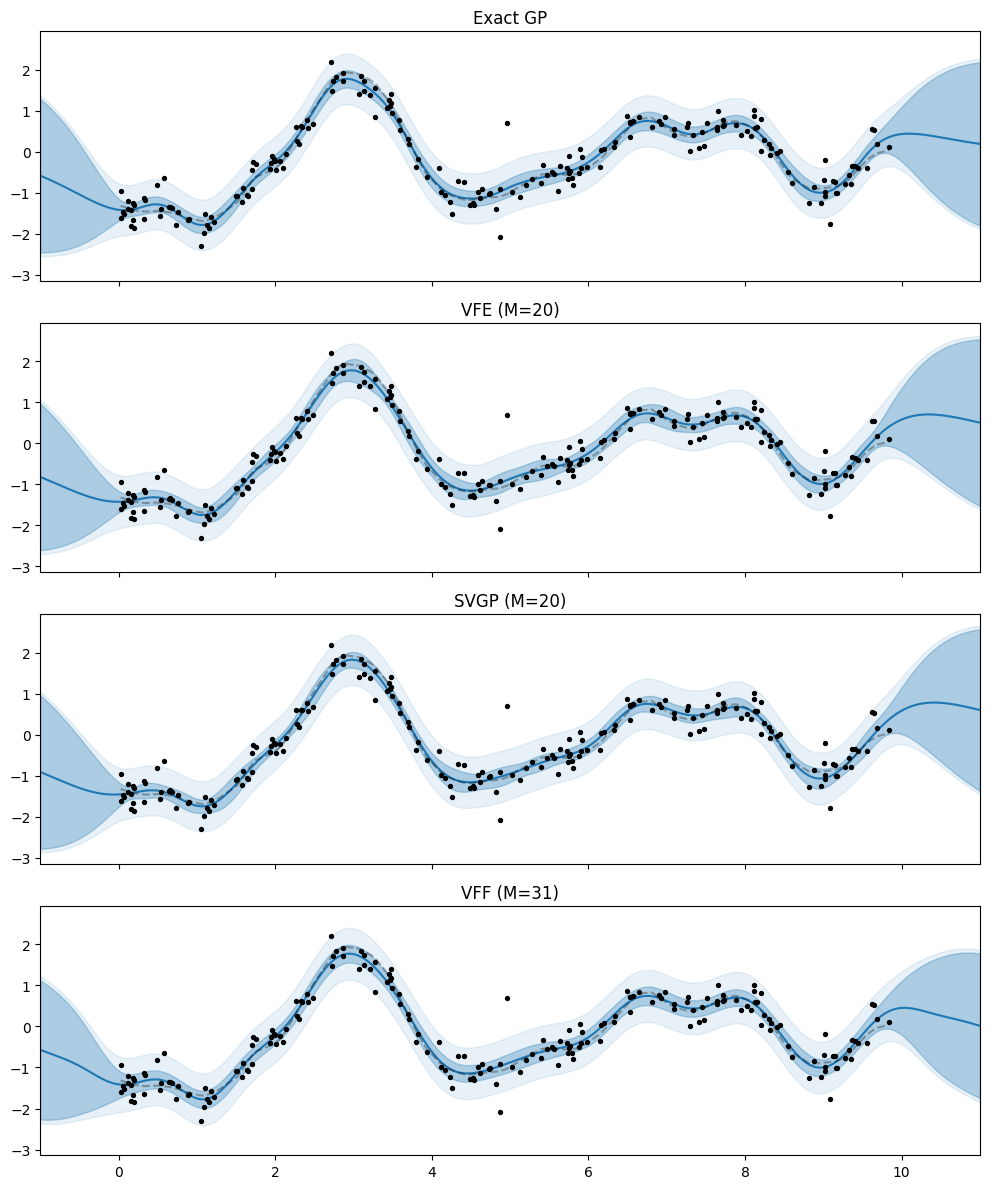

In [13]:
fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True, sharey=True)

for ax, (mu, sd_f, sd_y, title) in zip(
    axes,
    [
        (mu_gp, sd_gp, sd_gp_y, "Exact GP"),
        (mu_vfe, sd_vfe, sd_vfe_y, f"VFE (M={M})"),
        (mu_svgp, sd_svgp, sd_svgp_y, f"SVGP (M={M_svgp})"),
        (mu_vff, sd_vff, sd_vff_y, f"VFF (M={M_vff})"),
    ],
):
    ax.scatter(X_train, y_train, s=8, c="k", zorder=3)
    ax.plot(X_test, mu, "C0")
    ax.fill_between(X_test.ravel(), mu - 2 * sd_y, mu + 2 * sd_y, alpha=0.1, color="C0")
    ax.fill_between(X_test.ravel(), mu - 2 * sd_f, mu + 2 * sd_f, alpha=0.3, color="C0")
    ax.plot(X_train, f_train, "k--", alpha=0.3)
    ax.set_title(title)
    ax.set_xlim(-1, 11)

fig.tight_layout()

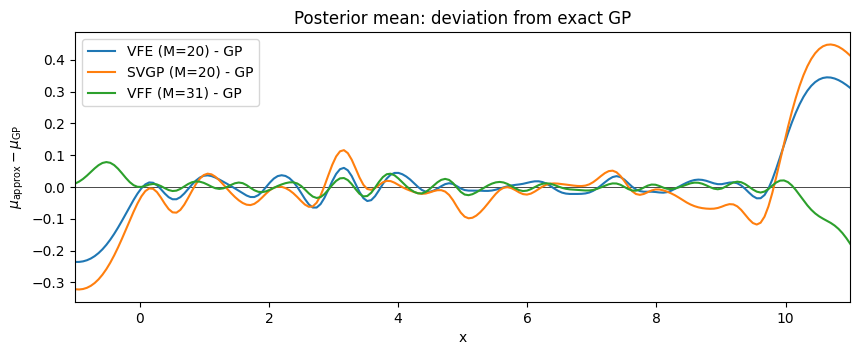

In [14]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.axhline(0, color="k", lw=0.5)
ax.plot(X_test, mu_vfe - mu_gp, label=f"VFE (M={M}) - GP")
ax.plot(X_test, mu_svgp - mu_gp, label=f"SVGP (M={M_svgp}) - GP")
ax.plot(X_test, mu_vff - mu_gp, label=f"VFF (M={M_vff}) - GP")
ax.set_xlim(-1, 11)
ax.set_xlabel("x")
ax.set_ylabel(r"$\mu_{\mathrm{approx}} - \mu_{\mathrm{GP}}$")
ax.set_title("Posterior mean: deviation from exact GP")
ax.legend()

## Wasserstein distance to the exact posterior

Each approximation defines a multivariate-normal posterior over `f(X_test)`. We can quantify how close it is to the exact GP posterior with the [Wasserstein-2 distance between Gaussians](https://en.wikipedia.org/wiki/Wasserstein_metric#Normal_distributions):

$$
W_2^2\big(\mathcal{N}(\mu_a, \Sigma_a),\, \mathcal{N}(\mu_b, \Sigma_b)\big)
= \|\mu_a - \mu_b\|^2 + \operatorname{tr}\!\Big(\Sigma_a + \Sigma_b - 2\big(\Sigma_a^{1/2} \Sigma_b \Sigma_a^{1/2}\big)^{1/2}\Big).
$$

The mean term is the squared difference shown above; the Bures term penalises any difference in covariance structure (variances *and* off-diagonal correlations).

Each model's `predict` only returns marginal variances, so we re-evaluate each posterior with full covariance using the trained shared parameters.

W2(VFE  || GP) = 1.5462
W2(SVGP || GP) = 2.0421
W2(VFF  || GP) = 0.6351


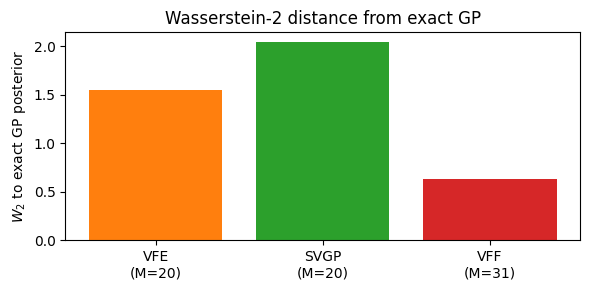

In [15]:
from pytensor.graph.replace import graph_replace
from scipy.linalg import sqrtm


def _replace(outs, model, sp, extra_vars=None, shared_extras=None):
    rep = model.replace_rvs_by_values(outs)
    rmap = dict(sp)
    if extra_vars is not None:
        rmap.update(zip(extra_vars, shared_extras))
    return [graph_replace(r, rmap, strict=False) for r in rep]


X_full = pt.matrix("X_full")
X_train_t = pt.as_tensor(X_train)
y_train_t = pt.as_tensor(y_train)

# --- Exact GP: dense posterior on X_test ---
sigma2_gp = gp.likelihood.sigma**2
K_xx = gp.kernel(X_train_t) + sigma2_gp * pt.eye(N)
K_xs = gp.kernel(X_train_t, X_full)
K_ss = gp.kernel(X_full)
mu_gp_sym = K_xs.T @ pt.linalg.solve(K_xx, y_train_t)
cov_gp_sym = K_ss - K_xs.T @ pt.linalg.solve(K_xx, K_xs)
predict_gp_full = pytensor.function(
    [X_full],
    _replace([mu_gp_sym, cov_gp_sym], gp_model, shared_params),
)

# --- VFE: collapsed q gives Sigma = Kuu + Kuf Kfu / sigma^2 ---
Z_v = vfe.inducing_variable.Z
sigma2_v = vfe.likelihood.sigma**2
Kuu_v = vfe.kernel(Z_v)
Kuf_v = vfe.kernel(Z_v, X_train_t)
Kus_v = vfe.kernel(Z_v, X_full)
Kss_v = vfe.kernel(X_full)
Sigma_v = Kuu_v + Kuf_v @ Kuf_v.T / sigma2_v
mu_vfe_sym = Kus_v.T @ pt.linalg.solve(Sigma_v, Kuf_v @ y_train_t / sigma2_v)
cov_vfe_sym = Kss_v - Kus_v.T @ (pt.linalg.inv(Kuu_v) - pt.linalg.inv(Sigma_v)) @ Kus_v
predict_vfe_full = pytensor.function(
    [X_full],
    _replace(
        [mu_vfe_sym, cov_vfe_sym],
        vfe_model,
        shared_params_vfe,
        extra_vars=[Z_v],
        shared_extras=shared_extras_vfe,
    ),
)

# --- SVGP-Points (whitened): A = R^{-1} Kus, R R^T = Kuu ---
Z_s = svgp.inducing_variable.Z
Kuu_s = svgp.kernel(Z_s)
Kus_s = svgp.kernel(Z_s, X_full)
Kss_s = svgp.kernel(X_full)
L_s = pt.linalg.cholesky(Kuu_s)
A_s = pt.linalg.solve_triangular(L_s, Kus_s, lower=True)
B_s = A_s.T @ q_sqrt_var
mu_svgp_sym = A_s.T @ q_mu_var
cov_svgp_sym = Kss_s - A_s.T @ A_s + B_s @ B_s.T
predict_svgp_full = pytensor.function(
    [X_full],
    _replace(
        [mu_svgp_sym, cov_svgp_sym],
        svgp_model,
        shared_params_svgp,
        extra_vars=[q_mu_var, q_sqrt_var, Z_s],
        shared_extras=shared_extras_svgp,
    ),
)

# --- VFF (whitened): structured Kuu_sqrt_solve handles R^{-1} without dense Cholesky ---
Kus_vff = f_vff.K_uf(svgp_vff.kernel, X_full)
Kss_vff = svgp_vff.kernel(X_full)
A_vff = f_vff.Kuu_sqrt_solve(svgp_vff.kernel, Kus_vff)
B_vff = A_vff.T @ q_sqrt_vff
mu_vff_sym = A_vff.T @ q_mu_vff
cov_vff_sym = Kss_vff - A_vff.T @ A_vff + B_vff @ B_vff.T
predict_vff_full = pytensor.function(
    [X_full],
    _replace(
        [mu_vff_sym, cov_vff_sym],
        vff_model,
        shared_params_vff,
        extra_vars=[q_mu_vff, q_sqrt_vff],
        shared_extras=shared_extras_vff,
    ),
)

mu_full_gp, Sigma_gp = predict_gp_full(X_test)
mu_full_vfe, Sigma_vfe = predict_vfe_full(X_test)
mu_full_svgp, Sigma_svgp = predict_svgp_full(X_test)
mu_full_vff, Sigma_vff = predict_vff_full(X_test)


def w2_gaussians(mu1, S1, mu2, S2, jitter=1e-6):
    n = len(mu1)
    S1j = S1 + jitter * np.eye(n)
    S2j = S2 + jitter * np.eye(n)
    S1_sqrt = sqrtm(S1j).real
    inner = sqrtm(S1_sqrt @ S2j @ S1_sqrt).real
    bures2 = max(0.0, float(np.trace(S1j) + np.trace(S2j) - 2 * np.trace(inner)))
    return float(np.sqrt(np.sum((mu1 - mu2) ** 2) + bures2))


w2_vfe = w2_gaussians(mu_full_gp, Sigma_gp, mu_full_vfe, Sigma_vfe)
w2_svgp = w2_gaussians(mu_full_gp, Sigma_gp, mu_full_svgp, Sigma_svgp)
w2_vff = w2_gaussians(mu_full_gp, Sigma_gp, mu_full_vff, Sigma_vff)

print(f"W2(VFE  || GP) = {w2_vfe:.4f}")
print(f"W2(SVGP || GP) = {w2_svgp:.4f}")
print(f"W2(VFF  || GP) = {w2_vff:.4f}")

fig, ax = plt.subplots(figsize=(6, 3))
labels = [f"VFE\n(M={M})", f"SVGP\n(M={M_svgp})", f"VFF\n(M={M_vff})"]
ax.bar(labels, [w2_vfe, w2_svgp, w2_vff], color=["C1", "C2", "C3"])
ax.set_ylabel(r"$W_2$ to exact GP posterior")
ax.set_title("Wasserstein-2 distance from exact GP")
fig.tight_layout()